#### Libraries

In [1]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.append(os.path.abspath(".."))

from libraries import torch, DataLoader, nn, optim, Accuracy, plt

#### Load variables

In [2]:
vars = torch.load('../saved_values/variables.pt', weights_only=False)
train_dataset = vars['train_dataset']
valid_loader = vars['valid_loader']

#### Utils

In [3]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#### Train model for batch size: 4, 8, 16

In [4]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

in_features = 12
out_features = 1
h1 = 64
h2 = 32

num_epochs = 600

loss_fn = nn.BCELoss()

for batch_size in [4, 8, 16]:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = nn.Sequential(nn.Linear(in_features, h1),
                          nn.ReLU(),
                          nn.Linear(h1, h2),
                          nn.ReLU(),
                          nn.Linear(h2, out_features),
                          nn.Sigmoid())
    
    optimizer = optim.SGD(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        loss_train = AverageMeter()
        acc_train = Accuracy(task='binary')

        for inputs, targets in train_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), targets)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_train.update(loss.item())
            acc_train(outputs.squeeze(), targets)
        
        loss_train_hist.append(loss_train.avg)
        acc_train_hist.append(acc_train.compute())

        with torch.no_grad():
            loss_valid = AverageMeter()
            acc_valid = Accuracy(task='binary')
            
            for inputs, targets in valid_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), targets)

                loss_valid.update(loss.item())
                acc_valid(outputs.squeeze(), targets)
        
        loss_valid_hist.append(loss_valid.avg)
        acc_valid_hist.append(acc_valid.compute())

        
        if epoch % 10 == 0:
            print(f'Epoch: {epoch} | {batch_size}')
            print(f'\tTrain Loss: {loss_train.avg:.4f} | Train Accuracy: {acc_train.compute():.4f}')
            print(f'\tValidation Loss: {loss_valid.avg:.4f} | Validation Accuracy: {acc_valid.compute():.4f}\n')

Epoch: 0 | 4
	Train Loss: 0.7067 | Train Accuracy: 0.3769
	Validation Loss: 0.7044 | Validation Accuracy: 0.3869

Epoch: 10 | 4
	Train Loss: 0.6743 | Train Accuracy: 0.6734
	Validation Loss: 0.6726 | Validation Accuracy: 0.6834

Epoch: 20 | 4
	Train Loss: 0.6506 | Train Accuracy: 0.6834
	Validation Loss: 0.6495 | Validation Accuracy: 0.6834

Epoch: 30 | 4
	Train Loss: 0.6315 | Train Accuracy: 0.6834
	Validation Loss: 0.6307 | Validation Accuracy: 0.6834

Epoch: 40 | 4
	Train Loss: 0.6144 | Train Accuracy: 0.6834
	Validation Loss: 0.6138 | Validation Accuracy: 0.6834

Epoch: 50 | 4
	Train Loss: 0.5980 | Train Accuracy: 0.6834
	Validation Loss: 0.5974 | Validation Accuracy: 0.6884

Epoch: 60 | 4
	Train Loss: 0.5827 | Train Accuracy: 0.6985
	Validation Loss: 0.5805 | Validation Accuracy: 0.6985

Epoch: 70 | 4
	Train Loss: 0.5634 | Train Accuracy: 0.7085
	Validation Loss: 0.5625 | Validation Accuracy: 0.7085

Epoch: 80 | 4
	Train Loss: 0.5457 | Train Accuracy: 0.7286
	Validation Loss: 0.54

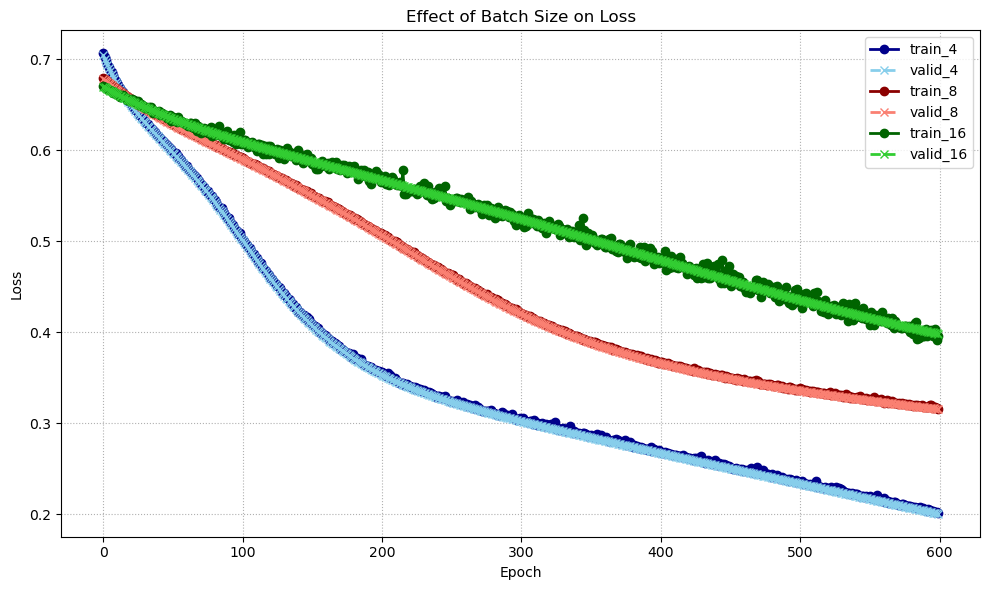

In [5]:
plt.figure(figsize=(10,6))

# Batch Size = 4
plt.plot(
    range(num_epochs),
    loss_train_hist[0:num_epochs],
    color='darkblue',
    linewidth=2,
    marker='o',
    label='train_4'
)

plt.plot(
    range(num_epochs),
    loss_valid_hist[0:num_epochs],
    color='skyblue',
    linewidth=2,
    linestyle='--',
    marker='x',
    label='valid_4'
)

# Batch Size = 8
plt.plot(
    range(num_epochs),
    loss_train_hist[num_epochs:2*num_epochs],
    color='darkred',
    linewidth=2,
    marker='o',
    label='train_8'
)

plt.plot(
    range(num_epochs),
    loss_valid_hist[num_epochs:2*num_epochs],
    color='salmon',
    linewidth=2,
    linestyle='--',
    marker='x',
    label='valid_8'
)

# Batch Size = 16
plt.plot(
    range(num_epochs),
    loss_train_hist[2*num_epochs:3*num_epochs],
    color='darkgreen',
    linewidth=2,
    marker='o',
    label='train_16'
)

plt.plot(
    range(num_epochs),
    loss_valid_hist[2*num_epochs:3*num_epochs],
    color='limegreen',
    linewidth=2,
    linestyle='--',
    marker='x',
    label='valid_16'
)

plt.title("Effect of Batch Size on Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

plt.savefig("../images/loss_batch_size.png", bbox_inches='tight')

plt.show()